In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Load full dataset
train = pd.read_csv('../data/raw/fraudTrain.csv')

# Build the transaction graph
# Nodes: cardholders (cc_num) and merchants
# Edges: transactions between them
#
# NOTE: this dataset only has 983 unique cards and 693 unique merchants
# but 1.3M transaction rows, so most (card, merchant) pairs repeat many
# times (up to 24x). Adding one edge per row with plain add_edge() would
# silently overwrite 'amount'/'is_fraud' with whatever the LAST transaction
# for that pair happened to be, discarding fraud signal from every earlier
# transaction on a repeated pair. Aggregate per pair first instead, so each
# edge carries transaction_count / fraud_count / amount totals.
train['card_node'] = 'card_' + train['cc_num'].astype(str)
train['merchant_node'] = 'merchant_' + train['merchant'].astype(str)

edge_stats = (
    train
    .groupby(['card_node', 'merchant_node'])
    .agg(
        transaction_count=('amt', 'size'),
        fraud_count=('is_fraud', 'sum'),
        total_amount=('amt', 'sum'),
        avg_amount=('amt', 'mean'),
    )
    .reset_index()
)

G = nx.Graph()
G.add_edges_from(
    (row.card_node, row.merchant_node, {
        'transaction_count': row.transaction_count,
        'fraud_count': row.fraud_count,
        'total_amount': row.total_amount,
        'avg_amount': row.avg_amount,
    })
    for row in edge_stats.itertuples()
)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}  (unique card-merchant pairs)")
print(f"Transactions represented: {edge_stats['transaction_count'].sum():,} / {len(train):,}")
print(f"Is bipartite: {nx.is_bipartite(G)}")

Nodes: 1676
Edges: 479072  (unique card-merchant pairs)
Transactions represented: 1,296,675 / 1,296,675
Is bipartite: True


#### Separate the two node types

In [2]:
# In a bipartite graph, nodes split into two sets
# NetworkX can find this partition for us
cardholder_nodes, merchant_nodes = nx.bipartite.sets(G)

print(f"Unique cardholders: {len(cardholder_nodes)}")
print(f"Unique merchants: {len(merchant_nodes)}")
print(f"Total nodes: {len(cardholder_nodes) + len(merchant_nodes)}")

# verify they sum to total
assert len(cardholder_nodes) + len(merchant_nodes) == G.number_of_nodes()
print("Partition verified correctly")

Unique cardholders: 983
Unique merchants: 693
Total nodes: 1676
Partition verified correctly


#### Degree analysis

In [3]:
# Degree of every node
degree_dict = dict(G.degree())

# Separate degrees by node type
cardholder_degrees = {
    node: degree_dict[node] 
    for node in cardholder_nodes
}

merchant_degrees = {
    node: degree_dict[node] 
    for node in merchant_nodes
}

# Convert to series for easy analysis
ch_deg_series = pd.Series(cardholder_degrees)
mer_deg_series = pd.Series(merchant_degrees)

print("=== CARDHOLDER DEGREE STATS ===")
print(ch_deg_series.describe())

print("\n=== MERCHANT DEGREE STATS ===")
print(mer_deg_series.describe())

print(f"\nHighest degree merchant: {mer_deg_series.idxmax()}")
print(f"Degree: {mer_deg_series.max()}")

=== CARDHOLDER DEGREE STATS ===
count    983.000000
mean     487.357070
std      174.672722
min        6.000000
25%      357.000000
50%      524.000000
75%      614.000000
max      678.000000
dtype: float64

=== MERCHANT DEGREE STATS ===
count    693.000000
mean     691.301587
std      100.624725
min      426.000000
25%      673.000000
50%      720.000000
75%      764.000000
max      863.000000
dtype: float64

Highest degree merchant: merchant_fraud_Kilback LLC
Degree: 863


#### Visualise degree distribution

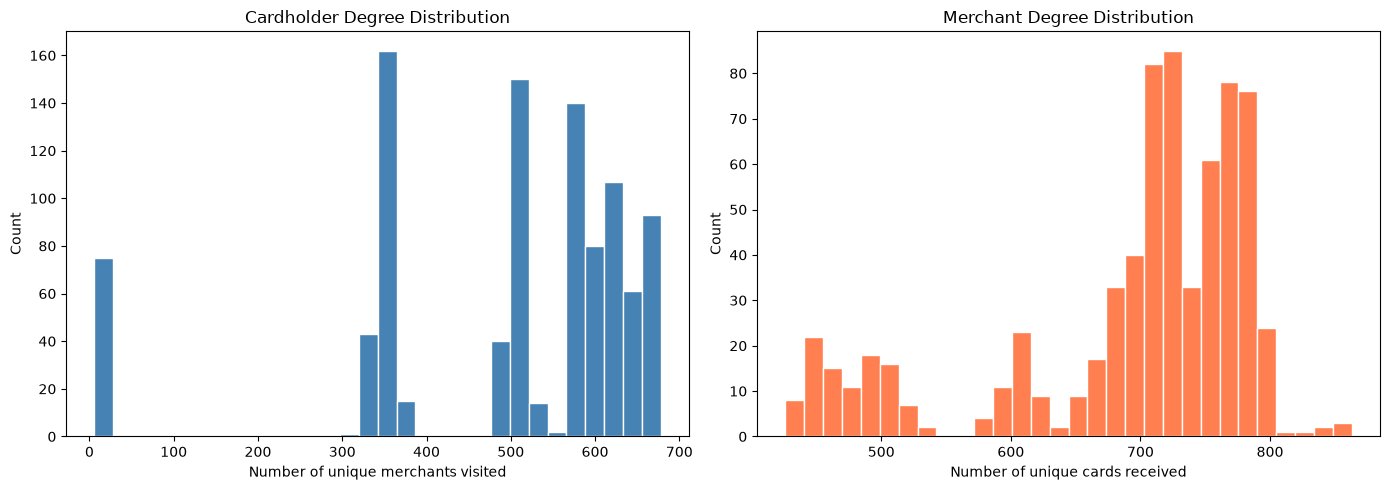

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cardholder degree distribution
axes[0].hist(ch_deg_series.values, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Cardholder Degree Distribution')
axes[0].set_xlabel('Number of unique merchants visited')
axes[0].set_ylabel('Count')

# Merchant degree distribution  
axes[1].hist(mer_deg_series.values, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Merchant Degree Distribution')
axes[1].set_xlabel('Number of unique cards received')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/figures/degree_distributions.png', dpi=150)
plt.show()

In [5]:
# For each merchant, calculate:
# 1. Their degree (unique cards)
# 2. How many of their transactions were fraudulent
# 3. Their fraud rate
#
# Edges now hold aggregated per-pair stats (transaction_count, fraud_count)
# rather than one edge per transaction, since a plain edge per row loses
# repeat transactions on the same (card, merchant) pair — see the graph
# construction cell.

merchant_fraud_stats = []

for merchant in merchant_nodes:
    edges = G.edges(merchant, data=True)
    
    total_transactions = 0
    fraud_transactions = 0
    
    for _, _, edge_data in edges:
        total_transactions += edge_data.get('transaction_count', 0)
        fraud_transactions += edge_data.get('fraud_count', 0)
    
    merchant_fraud_stats.append({
        'merchant': merchant,
        'degree': degree_dict[merchant],
        'total_transactions': total_transactions,
        'fraud_transactions': fraud_transactions,
        'fraud_rate': fraud_transactions / total_transactions if total_transactions > 0 else 0
    })

merchant_df = pd.DataFrame(merchant_fraud_stats)

print("=== HIGH FRAUD RATE MERCHANTS ===")
print(merchant_df[merchant_df['fraud_rate'] > 0].sort_values(
    'fraud_rate', ascending=False
).head(10))

=== HIGH FRAUD RATE MERCHANTS ===
                                          merchant  degree  \
16                      merchant_fraud_Kozey-Boehm     704   
169     merchant_fraud_Herman, Treutel and Dickens     625   
86                  merchant_fraud_Kerluke-Abshire     697   
43                        merchant_fraud_Brown PLC     585   
639                     merchant_fraud_Goyette Inc     720   
97                       merchant_fraud_Terry-Huel     730   
570                        merchant_fraud_Jast Ltd     723   
77    merchant_fraud_Schmeler, Bashirian and Price     717   
107                  merchant_fraud_Boyer-Reichert     723   
547  merchant_fraud_Langworth, Boehm and Gulgowski     728   

     total_transactions  fraud_transactions  fraud_rate  
16                 1866                  48    0.025723  
169                1300                  33    0.025385  
86                 1838                  41    0.022307  
43                 1176                  26    0.02

#### Formalizing the thesis connection

In [6]:
# Your thesis showed fraudulent merchants structurally resemble
# dominating vertices over independent sets of victim cardholders
# Let's verify this formally

# For each merchant, check if their cardholder neighbourhood
# forms an independent set (no two cardholders share other merchants)
#
# NOTE ON SCALE: at full dataset size this bipartite graph is nearly
# complete (an average card connects to ~70% of merchants and vice versa),
# so an all-pairs comparison of a merchant's ~700-card neighbourhood is
# expensive, and doing that for all 693 merchants isn't practical here.
# Changes from the original version:
#   1. Fixed a real perf bug — it was rebuilding each cardholder's
#      neighbour-merchant set from scratch on every single pair instead
#      of once, which made the loop O(deg^3) instead of O(deg^2).
#   2. Restricted the analysis to a fixed sample of merchants instead of
#      all 693, which keeps total runtime to a few minutes.
#   3. Labelling: "has any fraud" is degenerate at full scale — merchants
#      average ~1,800 transactions against a 0.58% overall fraud rate, so
#      nearly every merchant has *some* fraud by chance (confirmed: a
#      first pass sampling uniformly at random came back 100% "has fraud").
#      Compare fraud_rate quartiles instead (top vs bottom 25% of
#      merchant_df['fraud_rate']), and sample from each group directly
#      rather than sampling uniformly at random, since a random sample
#      would mostly land in the flat middle of the distribution.

import random

def neighbourhood_independence_ratio(merchant, neighbours, card_neighbour_sets):
    """
    Measures how 'independent' a merchant's cardholder neighbourhood is.
    
    An independent set means no two neighbours share another merchant.
    Value of 1.0 = perfect independent set = fraud signal
    Value near 0 = highly interconnected neighbours = legitimate merchant
    
    This connects directly to Theorem 4.2.2 in Tshepo's thesis:
    fraudulent merchants dominate independent sets of victim cardholders,
    forming subgraphs isomorphic to K_{1,n}
    """
    if len(neighbours) < 2:
        return 1.0  # Single neighbour is trivially independent
    
    # card_neighbour_sets is precomputed once outside this function, so
    # each cardholder's merchant-neighbour set is only built a single time
    shared_connections = 0
    total_pairs = 0
    
    for i in range(len(neighbours)):
        merchants_i = card_neighbour_sets[neighbours[i]]
        for j in range(i + 1, len(neighbours)):
            total_pairs += 1
            merchants_j = card_neighbour_sets[neighbours[j]]
            # Do they share any other merchants besides this one?
            if merchants_i & merchants_j - {merchant}:
                shared_connections += 1
    
    # Independence ratio: 1 = fully independent (fraud signal)
    #                     0 = fully interconnected (legitimate)
    return 1 - (shared_connections / total_pairs)

# Precompute once: each cardholder's set of merchant neighbours
card_neighbour_sets = {c: set(G.neighbors(c)) for c in cardholder_nodes}

# Fraud-rate quartile groups (top/bottom 25% of merchants by fraud_rate)
high_cutoff = merchant_df['fraud_rate'].quantile(0.75)
low_cutoff = merchant_df['fraud_rate'].quantile(0.25)
high_fraud_merchants = merchant_df.loc[merchant_df['fraud_rate'] >= high_cutoff, 'merchant'].tolist()
low_fraud_merchants = merchant_df.loc[merchant_df['fraud_rate'] <= low_cutoff, 'merchant'].tolist()

print(f"High fraud_rate group (>= {high_cutoff:.4f}): {len(high_fraud_merchants)} merchants")
print(f"Low fraud_rate group (<= {low_cutoff:.4f}): {len(low_fraud_merchants)} merchants")

random.seed(42)
GROUP_SAMPLE_SIZE = 15
sampled_high = random.sample(high_fraud_merchants, min(GROUP_SAMPLE_SIZE, len(high_fraud_merchants)))
sampled_low = random.sample(low_fraud_merchants, min(GROUP_SAMPLE_SIZE, len(low_fraud_merchants)))
sampled_merchants = sampled_high + sampled_low
merchant_fraud_group = {m: 'High fraud_rate' for m in sampled_high}
merchant_fraud_group.update({m: 'Low fraud_rate' for m in sampled_low})

print(f"\nCalculating neighbourhood independence ratios for {len(sampled_merchants)} merchants "
      f"({len(sampled_high)} high fraud_rate + {len(sampled_low)} low fraud_rate)...")
print("(expect a couple of minutes given full-dataset graph density)")
print()

merchant_independence = []

for n, merchant in enumerate(sampled_merchants, 1):
    neighbours = [c for c in G.neighbors(merchant) if c in cardholder_nodes]
    ratio = neighbourhood_independence_ratio(merchant, neighbours, card_neighbour_sets)
    merchant_independence.append({
        'merchant': merchant,
        'degree': degree_dict[merchant],
        'independence_ratio': ratio,
        'fraud_group': merchant_fraud_group[merchant]
    })
    if n % 5 == 0 or n == len(sampled_merchants):
        print(f"  {n}/{len(sampled_merchants)} merchants processed")

independence_df = pd.DataFrame(merchant_independence)

# Compare high vs low fraud_rate merchants
print("\n=== INDEPENDENCE RATIO BY FRAUD_RATE GROUP (sampled) ===")
print(independence_df.groupby('fraud_group')['independence_ratio'].describe())
print()
print("Interpretation:")
print("  Ratio closer to 1.0 = isolated victim clusters")
print("  Ratio closer to 0.0 = interconnected customers")

High fraud_rate group (>= 0.0078): 174 merchants
Low fraud_rate group (<= 0.0017): 174 merchants

Calculating neighbourhood independence ratios for 30 merchants (15 high fraud_rate + 15 low fraud_rate)...
(expect a couple of minutes given full-dataset graph density)



  5/30 merchants processed


  10/30 merchants processed


  15/30 merchants processed


  20/30 merchants processed


  25/30 merchants processed


  30/30 merchants processed

=== INDEPENDENCE RATIO BY FRAUD_RATE GROUP (sampled) ===
                 count      mean       std  min  25%       50%       75%  \
fraud_group                                                                
High fraud_rate   15.0  0.000017  0.000027  0.0  0.0  0.000006  0.000011   
Low fraud_rate    15.0  0.000000  0.000000  0.0  0.0  0.000000  0.000000   

                      max  
fraud_group                
High fraud_rate  0.000074  
Low fraud_rate   0.000000  

Interpretation:
  Ratio closer to 1.0 = isolated victim clusters
  Ratio closer to 0.0 = interconnected customers


#### Eccentricity analysis

In [7]:
# The thesis defines eccentricity as:
# e(v) = max{d(v,u) | u ∈ V(G)} basically the highest among the shortest distances
# To find the eccentricity e(v) of a specific vertex v:
# Determine the shortest path (distance) from v to every other vertex in the graph.
# Identify the highest value among these distances.

# In the transaction graph:
# High eccentricity merchant = peripheral, disconnected from main network
# Low eccentricity merchant = central, well connected

# The thesis predicts fraudulent merchants have HIGH eccentricity
# in the legitimate network (boundary vertices)

# nx.eccentricity requires a connected graph — check first. At full scale
# this graph turns out to be fully connected (only 983 cards / 693
# merchants across 1.3M transactions means almost everyone eventually
# transacts with almost everyone), but keep the check as a safeguard.
print(f"Is connected: {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

components = list(nx.connected_components(G))
largest_cc = max(components, key=len)
G_main = G.subgraph(largest_cc).copy()

print(f"Largest component: {G_main.number_of_nodes()} nodes "
      f"({G_main.number_of_nodes() / G.number_of_nodes():.1%} of the full graph)")

# Reuse the same high/low fraud_rate merchant sample as the
# independence-ratio cell, both so the two analyses are directly
# comparable and because plain nx.eccentricity(G_main) runs a BFS from
# every one of the 1676 nodes, which is too slow at this graph's density.
# Passing v= limits the BFS runs to just the sampled merchants — each
# resulting eccentricity value is still exact, computed against the whole
# graph, just not computed for every node.
sample_nodes = [m for m in sampled_merchants if m in G_main]
eccentricity_dict = nx.eccentricity(G_main, v=sample_nodes)

merchant_eccentricity = []

for merchant, ecc in eccentricity_dict.items():
    merchant_eccentricity.append({
        'merchant': merchant,
        'eccentricity': ecc,
        'degree': degree_dict[merchant],
        'fraud_group': merchant_fraud_group[merchant]
    })

eccentricity_df = pd.DataFrame(merchant_eccentricity)

print(f"\nMerchants included: {len(eccentricity_df)} / {len(sampled_merchants)} sampled")

print("\n=== ECCENTRICITY BY FRAUD_RATE GROUP (sampled) ===")
print(eccentricity_df.groupby('fraud_group')['eccentricity'].describe())
print()
print("Interpretation:")
print("  High eccentricity = peripheral/boundary merchant")
print("  Low eccentricity  = central, well-connected merchant")

Is connected: True
Number of connected components: 1


Largest component: 1676 nodes (100.0% of the full graph)



Merchants included: 30 / 30 sampled

=== ECCENTRICITY BY FRAUD_RATE GROUP (sampled) ===
                 count  mean  std  min  25%  50%  75%  max
fraud_group                                               
High fraud_rate   15.0   3.0  0.0  3.0  3.0  3.0  3.0  3.0
Low fraud_rate    15.0   3.0  0.0  3.0  3.0  3.0  3.0  3.0

Interpretation:
  High eccentricity = peripheral/boundary merchant
  Low eccentricity  = central, well-connected merchant


#### Findings: thesis-derived features don't survive full-scale density

Both graph features were re-tested at full dataset scale (1.3M transactions,
983 cards, 693 merchants) instead of the original 10k-row prototype, comparing
the top vs bottom fraud_rate quartile of merchants (15 sampled per group):

| Feature | 10k-row sample | Full dataset (quartile groups) |
|---|---|---|
| Independence ratio | mean 0.76, visible spread | High: 0.000017, Low: 0.000000 — both ≈ 0 |
| Eccentricity | not yet tested | 3.0 for every sampled merchant, zero variance in both groups |

**Conclusion:** neither feature discriminates fraud-heavy from fraud-light
merchants at full scale. The signal seen on the 10k-row prototype was a
sparse-sampling artifact, not a real structural pattern. This dataset's
transaction graph only has 983 cards and 693 merchants behind 1.3M
transactions, so it is nearly a complete bipartite graph (~70% density each
side) — there's essentially no "independent victim cluster" or "peripheral
merchant" structure left to detect once every cardholder has transacted with
most merchants. The thesis's structural claims (isolated neighbourhoods,
high-eccentricity boundary vertices) assume a sparser network than this
dataset actually has at scale.

**Implication for the model:** these two features are unlikely to carry
useful signal for the classifier as defined. Worth reconsidering either the
graph construction (e.g. restricting edges to a shorter time window per
cardholder, rather than all transactions ever) or dropping these two
graph-theoretic features in favour of the non-graph behavioural features
from the earlier feature-engineering pass.